## Imports and utility definitions 

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

#add ../ to the path
import sys
sys.path.insert(0, '../')

import evaluate_utils
import viz_utils
import importlib
import data_utils
importlib.reload(evaluate_utils)
importlib.reload(viz_utils)
importlib.reload(data_utils)
from evaluate_utils import *
from viz_utils import viz
from data_utils import *

import numpy as np

# Function to sum, returning NaN if all values are NaN
def safe_nansum(arr, axis=0):
    sum_results = np.nansum(arr, axis=axis)
    # Check if all values are NaN along the axis
    all_nan = np.all(np.isnan(arr), axis=axis)
    # Where all values are NaN, set the sum to NaN
    sum_results[all_nan] = np.nan
    return sum_results


In [19]:
five_batch_results = viz.result_data('/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf/5_batches_64_evals', num_evals = 64, num_batches=5)
full_test_set_results = viz.result_data('/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf/full_set_4_evals', num_evals = 4)
RRUFF_non_aug_model = viz.result_data('/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf/RRUFF_data_test_only_using_amcsd', num_evals = 64)
RRUFF_aug_model = viz.result_data('/home/gridsan/tmackey/hydra/singlerun/2024-01-29/augmented_vae_nopf/RRUFF_data_test_only_using_amcsd', num_evals = 64)    

100%|██████████| 64/64 [00:00<00:00, 72.24it/s] 


## Load in the test csv 

In [20]:
test_csv = pd.read_csv("/home/gridsan/tmackey/cdvae/data/mp_20_final/test.csv")

test_set_rmsd_results = full_test_set_results.total_rmsd
test_set_rmsd_results_across_4_batches = safe_nansum(test_set_rmsd_results, axis=0)

#find all values in test_set_rmsd_results_across_4_batches that are not nan 
test_set_rmsd_results_across_4_batches_not_nan = test_set_rmsd_results_across_4_batches[~np.isnan(test_set_rmsd_results_across_4_batches)]

with open('unique_materials.txt') as f:
    unique_materials = f.read().splitlines()
    print("length of unique materials: ", len(unique_materials))

#find the index of all rows in test_csv that have a 'material_id' that is in unique_materials
unique_materials_csv =  test_csv[test_csv['material_id'].isin(unique_materials)]
unique_materials_indices = np.array(test_csv[test_csv['material_id'].isin(unique_materials)].index)
print("length of unique materials csv: ", len(unique_materials_csv))

length of unique materials:  197
length of unique materials csv:  197


## Perform analysis on the structures without structure type analogues in the training set 

In [24]:
def analysis(data):
    # Removing NaN values
    valid_data = data[~np.isnan(data)]

    # Percentage of non-NaN values
    percentage_non_nan = (len(valid_data) / len(data)) * 100

    # Average of non-NaN values
    average_non_nan = np.mean(valid_data)

    # Histogram of non-NaN values
    plt.figure(figsize=(5, 3))
    plt.hist(valid_data, bins=20, color='skyblue', edgecolor='black')
    plt.title('Histogram of Non-NaN Values')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    print('Percentage of non-NaN values: {:.2f}%'.format(percentage_non_nan))
    print('Average of non-NaN values: {:.4f}'.format(average_non_nan))
    print('Number of non-NaN values: {}'.format(len(valid_data)))
    return None

results across the full test set


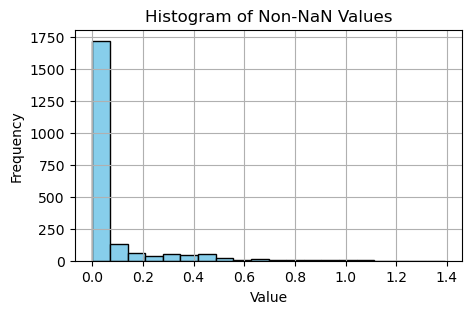

Percentage of non-NaN values: 47.89%
Average of non-NaN values: 0.0896
Number of non-NaN values: 2166


In [25]:
print("results across the full test set")
analysis(test_set_rmsd_results_across_4_batches)

results across novel structure types


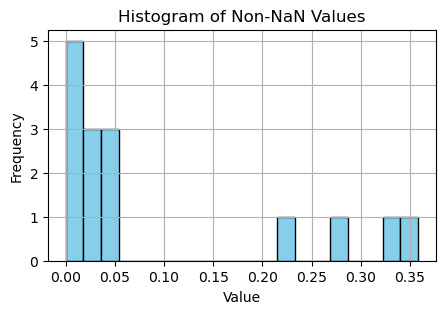

Percentage of non-NaN values: 7.61%
Average of non-NaN values: 0.0969
Number of non-NaN values: 15


In [26]:
print("results across novel structure types")
analysis(test_set_rmsd_results_across_4_batches[unique_materials_indices])

## Get predicted and ground truth structures for all non-NaN predictions in the test set  

In [49]:
def grab_unique_structure_type_results(test_set_rmsd_results, unique_materials_indices, test_set_results, num_evals = 4):
    """ 
    make a dictionary where the key is the eval num (0-(num_evals-1)) and the value is an empty list
    we will eventually populate it with 
      1. the index of the unique material
      2. the rmsd value associated with the unique material
      3. the ground truth structure for the material
      4. the predicted structure for the material
    """

    # for every column in test_set_rmsd_results associated with a unique material index, find the rows in which the value is not nan
    
    unique_materials_indices_dict = {i: [] for i in range(num_evals)}
    for row_i in range(num_evals): 
        for col_i in list(unique_materials_indices):
            value = test_set_rmsd_results[row_i, col_i]
            
            #if the value is not nan, add the index to the list associated with the eval number
            if not np.isnan(value):
                #get the ground truth structure for the material
                gt_structure = test_set_results.gt[row_i][col_i] # this get the gt 
                pred_structure = test_set_results.gt[row_i][col_i] # this get the pred result
                unique_materials_indices_dict[row_i].append((col_i,value, gt_structure, pred_structure))


In [52]:
non_nan_predcitions = grab_unique_structure_type_results(test_set_rmsd_results, unique_materials_indices, full_test_set_results)
#save the non_nan_predictions to a pt file
torch.save(non_nan_predcitions, 'result_data/unique_structure_type_results.pt')